In [2]:
import os, json

KAGGLE_USERNAME = ""
KAGGLE_KEY      = ""   # e.g. "abc123def456..."

assert KAGGLE_USERNAME and KAGGLE_KEY, "Fill in your Kaggle username and key above!"

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print(f'Kaggle API key installed for user: {KAGGLE_USERNAME}')

In [3]:
import time

print(">>> Downloading ISIC 2019 dataset from Kaggle...")
t0 = time.time()
!kaggle datasets download -d salviohexia/isic-2019-skin-lesion-images-for-classification
print(f">>> Download complete in {time.time()-t0:.0f}s")

print(">>> Unzipping...")
t0 = time.time()
!unzip -q isic-2019-skin-lesion-images-for-classification.zip -d isic2019
print(f">>> Unzip complete in {time.time()-t0:.0f}s")

print(">>> Contents:")
!ls -lh isic2019/

>>> Downloading ISIC 2019 dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
isic-2019-skin-lesion-images-for-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
>>> Download complete in 1s
>>> Unzipping...
replace isic2019/AK/ISIC_0024468.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace isic2019/AK/ISIC_0024470.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace isic2019/AK/ISIC_0024511.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace isic2019/AK/ISIC_0024646.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace isic2019/AK/ISIC_0024654.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace isic2019/AK/ISIC_0024707.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace isic2019/AK/ISIC_0024763.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace isic2019/AK/ISIC_0024771.jpg? [y]es, [n]o

## Imports

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load Labels and Map to Binary

The ISIC 2019 dataset has 8 diagnostic categories. We map them to binary:
- **Malignant:** MEL (melanoma), BCC (basal cell carcinoma), AK (actinic keratosis), SCC (squamous cell carcinoma)
- **Benign:** NV (melanocytic nevus), BKL (benign keratosis), DF (dermatofibroma), VASC (vascular lesion)

In [10]:
# Find the ground truth CSV
csv_candidates = [f for f in os.listdir('isic2019') if f.endswith('.csv') and 'GroundTruth' in f]
if not csv_candidates:
    csv_candidates = [f for f in os.listdir('isic2019') if f.endswith('.csv')]
print('CSV files found:', csv_candidates)

gt = pd.read_csv(os.path.join('isic2019', csv_candidates[0]))
print(f'Ground truth shape: {gt.shape}')
gt.head()

CSV files found: ['ISIC_2019_Training_GroundTruth.csv']
Ground truth shape: (25331, 10)


,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
MALIGNANT_CLASSES = ['MEL', 'BCC', 'AK', 'SCC']
BENIGN_CLASSES = ['NV', 'BKL', 'DF', 'VASC']

# Get the class for each image (column with the 1 value)
class_cols = [c for c in gt.columns if c in MALIGNANT_CLASSES + BENIGN_CLASSES]
print('Class columns found:', class_cols)

gt['class_name'] = gt[class_cols].idxmax(axis=1)
gt['malignant'] = gt['class_name'].isin(MALIGNANT_CLASSES).astype(int)

print(f'\nTotal images: {len(gt)}')
print(f'\nOriginal class distribution:')
print(gt['class_name'].value_counts())
print(f'\nBinary distribution:')
print(f'  Benign:    {(gt["malignant"] == 0).sum()}')
print(f'  Malignant: {(gt["malignant"] == 1).sum()}')

Class columns found: ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

Total images: 25331

Original class distribution:
class_name
NV      12875
MEL      4522
BCC      3323
BKL      2624
AK        867
SCC       628
VASC      253
DF        239
Name: count, dtype: int64

Binary distribution:
  Benign:    15991
  Malignant: 9340


## Load and Resize Images

In [12]:
IMG_SIZE = 224

extensions = ['.jpg', '.jpeg', '.png']
def find_image(image_id, img_dir):
    for ext in extensions:
        path = os.path.join(img_dir, image_id + ext)
        if os.path.exists(path):
            return path
    return None


In [13]:
from tqdm import tqdm

images = []
labels = []
skipped = 0

for _, row in tqdm(gt.iterrows(), total=len(gt), desc='Loading images'):
    image_id = row['image']
    # Dynamically point to the correct subdirectory based on the class
    current_img_dir = os.path.join('isic2019', str(row['class_name']))

    path = find_image(image_id, current_img_dir)
    if path is None:
        path = os.path.join(current_img_dir, image_id)

    if path is None or not os.path.exists(path):
        skipped += 1
        continue

    img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    images.append(np.asarray(img, dtype='uint8'))
    labels.append(row['malignant'])

X_all = np.array(images)
y_all = np.array(labels, dtype='float64')
print(f'\nLoaded: {len(X_all)} images, skipped: {skipped}')
print(f'Shape: {X_all.shape}')
del images, labels

Loading images: 100%|██████████| 25331/25331 [06:44<00:00, 62.61it/s]



Loaded: 25331 images, skipped: 0
Shape: (25331, 224, 224, 3)


## Train / Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
del X_all, y_all

print(f'Train: {X_train.shape[0]} images ({int(y_train.sum())} malignant, {int((1-y_train).sum())} benign)')
print(f'Test:  {X_test.shape[0]} images ({int(y_test.sum())} malignant, {int((1-y_test).sum())} benign)')

Train: 20264 images (7472 malignant, 12792 benign)
Test:  5067 images (1868 malignant, 3199 benign)


## Display Data

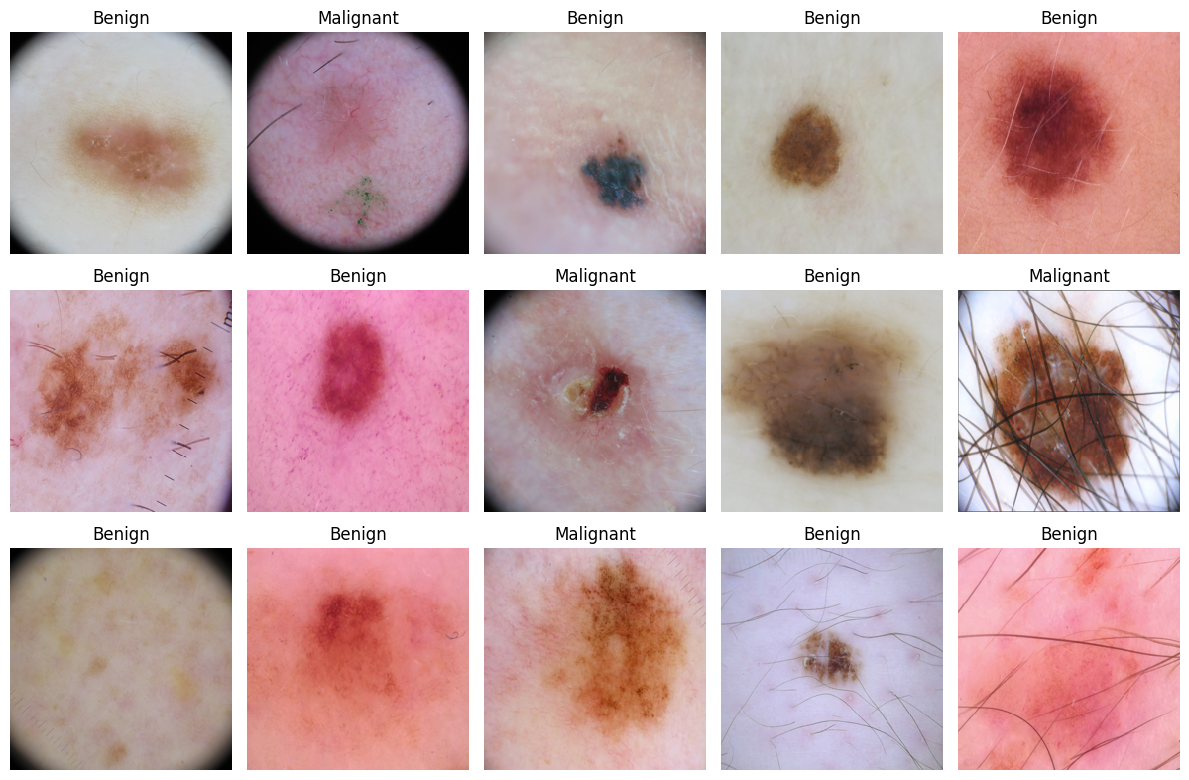

In [15]:
fig = plt.figure(figsize=(12, 8))
for i in range(1, 16):
    ax = fig.add_subplot(3, 5, i)
    ax.title.set_text('Benign' if y_train[i] == 0 else 'Malignant')
    plt.imshow(X_train[i], interpolation='nearest')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Dataset Balance

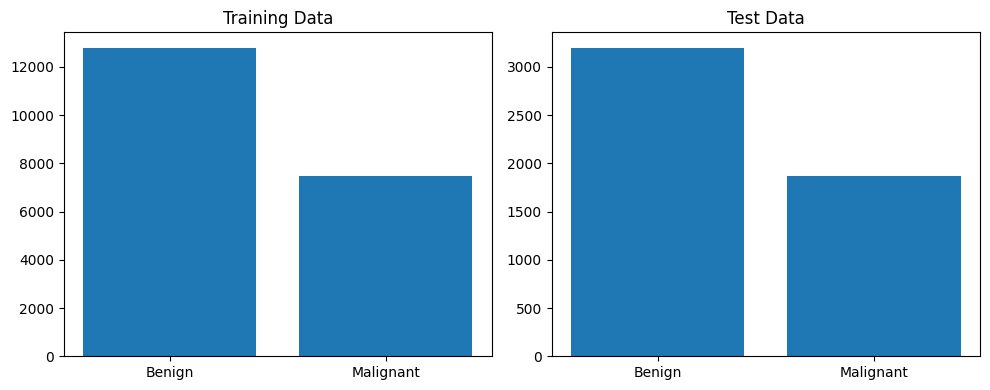

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar([0, 1], [int((y_train == 0).sum()), int((y_train == 1).sum())], tick_label=['Benign', 'Malignant'])
ax1.set_title('Training Data')
ax2.bar([0, 1], [int((y_test == 0).sum()), int((y_test == 1).sum())], tick_label=['Benign', 'Malignant'])
ax2.set_title('Test Data')
plt.tight_layout()
plt.show()

## Scale Values

In [17]:
import gc

# We avoid global scaling here to prevent RAM crashes!
# X_train = X_train / 255.
# X_test = X_test / 255.

gc.collect()
print("Data kept as uint8 in RAM to avoid OOM crashes.")

Data kept as uint8 in RAM to avoid OOM crashes.


## Baseline: SVM on Flat Pixels

In [18]:
import time
import numpy as np
from cuml.svm import SVC
from sklearn.metrics import accuracy_score

# SVMs are very memory intensive. To avoid OOM crashes on the flattened arrays,
# we will use a large subsample of 10,000 images for the baseline.
SVM_SUBSAMPLE = 10000

print(f">>> Subsampling and flattening data for SVM (using {SVM_SUBSAMPLE} samples)...")
rng = np.random.default_rng(42)
svm_idx = rng.choice(X_train.shape[0], size=SVM_SUBSAMPLE, replace=False)

# Cast to float32 and scale to [0, 1] JUST for the SVM subset to save memory
X_train_flat = X_train[svm_idx].reshape(SVM_SUBSAMPLE, -1).astype('float32') / 255.0
y_train_flat = y_train[svm_idx].astype('float32')

X_test_flat = X_test.reshape(X_test.shape[0], -1).astype('float32') / 255.0

print(f">>> Training cuML SVM on {X_train_flat.shape[0]} images...")
t0 = time.time()
# cuML SVC uses the GPU for training
svm = SVC()
svm.fit(X_train_flat, y_train_flat)
print(f">>> SVM training complete in {time.time()-t0:.0f}s")

print(">>> Evaluating SVM on full test set...")
# Process predictions in batches to avoid GPU OOM during inference
batch_size = 500
y_pred_svm = []
for i in range(0, X_test_flat.shape[0], batch_size):
    batch_pred = svm.predict(X_test_flat[i:i+batch_size])
    if hasattr(batch_pred, 'get'):
        batch_pred = batch_pred.get()
    y_pred_svm.extend(batch_pred)

svm_acc = accuracy_score(y_test, y_pred_svm)
print(f'>>> SVM Test Accuracy (trained on {SVM_SUBSAMPLE} samples): {svm_acc:.4f}')

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
>>> Subsampling and flattening data for SVM (using 10000 samples)...
>>> Training cuML SVM on 10000 images...
>>> SVM training complete in 10s
>>> Evaluating SVM on full test set...
>>> SVM Test Accuracy (trained on 10000 samples): 0.7379


## CNN Classifier

In [19]:
from tensorflow.keras import layers, models, Input

cnn = models.Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Rescaling(1./255), # <--- Scales the images to [0,1] on the fly!
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', name='last_conv'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
import time

t0 = time.time()
history = cnn.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))
print(f">>> CNN training complete in {time.time()-t0:.0f}s")

Epoch 1/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.6975 - loss: 0.5703 - val_accuracy: 0.7306 - val_loss: 0.5117
Epoch 2/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7251 - loss: 0.5272 - val_accuracy: 0.7275 - val_loss: 0.5370
Epoch 3/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7352 - loss: 0.5153 - val_accuracy: 0.7417 - val_loss: 0.5108
Epoch 4/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7448 - loss: 0.5040 - val_accuracy: 0.7387 - val_loss: 0.5007
Epoch 5/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7521 - loss: 0.4927 - val_accuracy: 0.7578 - val_loss: 0.4832
Epoch 6/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7567 - loss: 0.4800 - val_accuracy: 0.7500 - val_loss: 0.5304
Epoch 7/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7643 - loss: 0.4717 - val_accuracy: 0.7454 - val_loss: 0.5026
Epoch 8/10
634/634 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7777 - loss: 0.4525 - val_acc

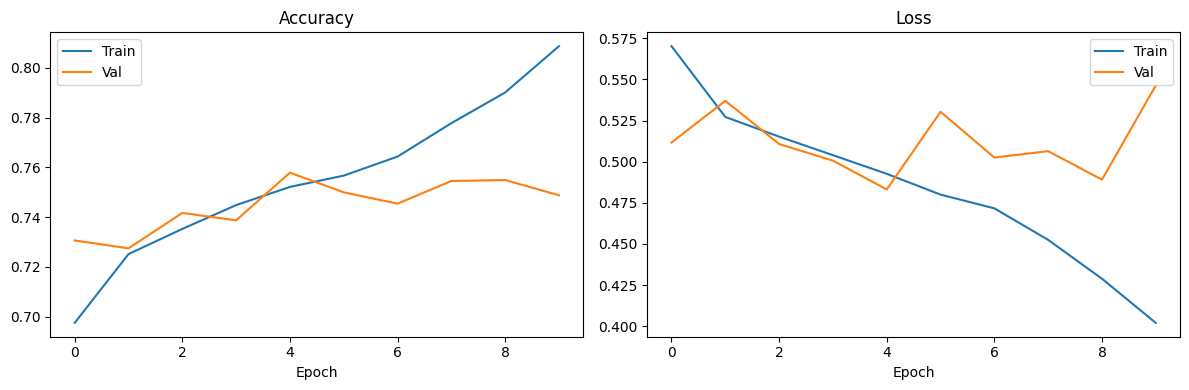

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.tight_layout()
plt.show()

In [22]:
test_loss, test_acc = cnn.evaluate(X_test, y_test)
print(f'CNN Test Accuracy: {test_acc:.4f}')
print(f'SVM Test Accuracy: {svm_acc:.4f}')

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7488 - loss: 0.5464
CNN Test Accuracy: 0.7488
SVM Test Accuracy: 0.7379


## Confusion Matrix and Per-Class Metrics

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Confusion Matrix (rows=true, cols=pred):
  TN=2679  FP=520
  FN=753  TP=1115

              precision    recall  f1-score   support

      Benign       0.78      0.84      0.81      3199
   Malignant       0.68      0.60      0.64      1868

    accuracy                           0.75      5067
   macro avg       0.73      0.72      0.72      5067
weighted avg       0.74      0.75      0.74      5067



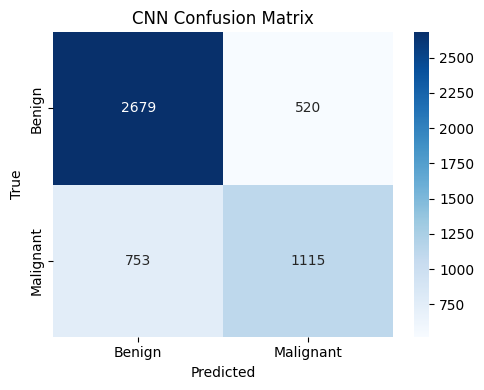

In [23]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = cnn.predict(X_test)
y_pred_cnn = (y_pred_prob >= 0.5).astype(int).flatten()

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
print('Confusion Matrix (rows=true, cols=pred):')
print(f'  TN={cm_cnn[0,0]}  FP={cm_cnn[0,1]}')
print(f'  FN={cm_cnn[1,0]}  TP={cm_cnn[1,1]}')
print()
print(classification_report(y_test, y_pred_cnn, target_names=['Benign', 'Malignant']))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('CNN Confusion Matrix')
plt.tight_layout()
plt.show()

In [24]:
cnn.save('skin_cancer_model.keras')
print('Model saved.')

Model saved.


## Grad-CAM: What is the CNN looking at?

We apply Grad-CAM (Selvaraju et al., 2017) to the last convolutional layer of the CNN. The heatmap highlights image regions whose activations most influence the malignant-class score. This gives us a sanity check on whether the model focuses on lesion pixels or on surrounding artifacts (ruler markings, hair, skin tone background).

In [30]:
from matplotlib import cm as colormap
import tensorflow as tf
import numpy as np
from PIL import Image

LAST_CONV = 'last_conv'

def gradcam(img_batch, model, last_conv_layer_name=LAST_CONV):
    # 1. Model that maps inputs to the last conv layer
    last_conv_layer = model.get_layer(last_conv_layer_name)
    last_conv_model = tf.keras.Model(model.inputs, last_conv_layer.output)

    # 2. Model that maps the last conv layer to the final predictions
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    layer_idx = model.layers.index(last_conv_layer)
    for layer in model.layers[layer_idx+1:]:
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        # Get the feature map and explicitly watch it
        last_conv_output = last_conv_model(img_batch)
        tape.watch(last_conv_output)

        # Get the final prediction
        preds = classifier_model(last_conv_output)
        score = preds[:, 0]

    # Compute gradients of the score with respect to the feature map
    grads = tape.gradient(score, last_conv_output)

    # Average the gradients spatially
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map by its importance
    heatmap = last_conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU and normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), float(preds[0, 0])

def overlay(img_uint8, heatmap, alpha=0.45):
    h = np.array(Image.fromarray((heatmap * 255).astype('uint8')).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
    colored = (colormap.get_cmap('jet')(h / 255.0)[:, :, :3] * 255).astype('uint8')
    return (img_uint8 * (1 - alpha) + colored * alpha).astype('uint8')

>>> Generating Grad-CAM overlays for 8 test images...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipykernel_11879/2562100647.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colored = (colormap.get_cmap('jet')(h / 255.0)[:, :, :3] * 255).astype('uint8')


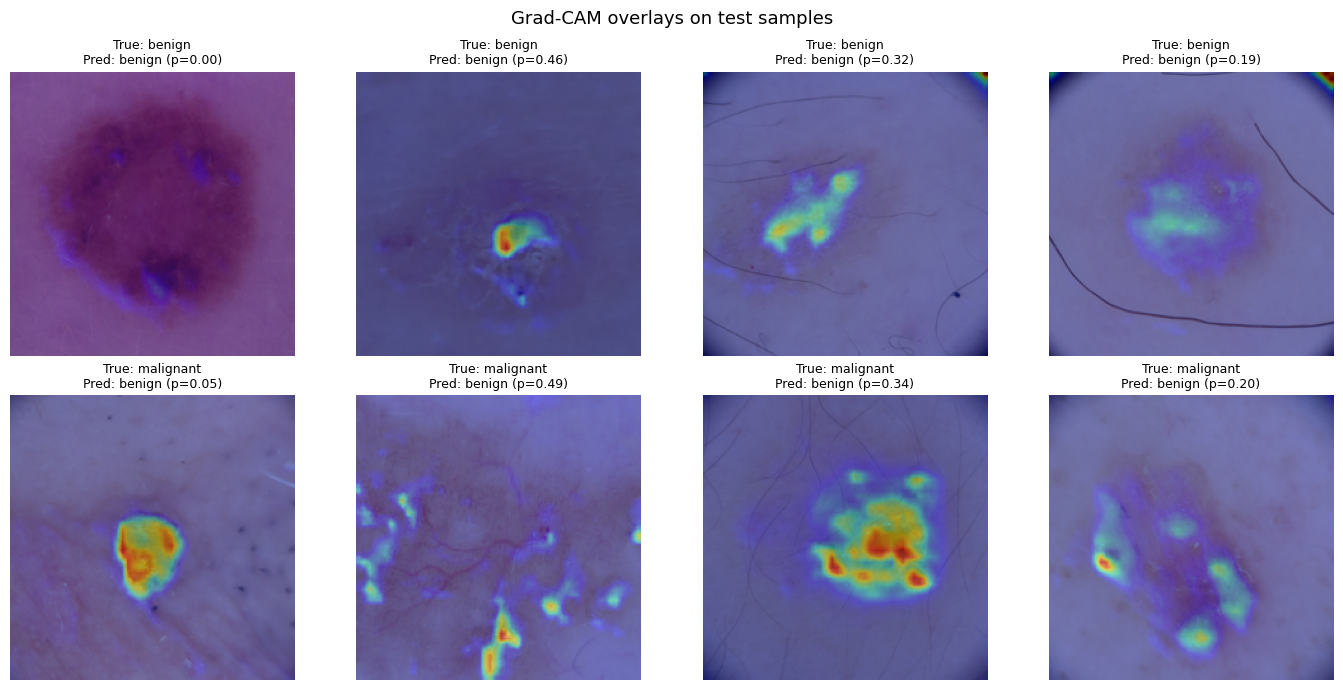

>>> Grad-CAM figure saved to gradcam_examples.png


In [31]:
print(">>> Generating Grad-CAM overlays for 8 test images...")

def sample_grid(class_value, n=4):
    idx = np.where(y_test == class_value)[0]
    rng = np.random.default_rng(42)
    return rng.choice(idx, size=n, replace=False)

benign_idx = sample_grid(0, 4)
malignant_idx = sample_grid(1, 4)

def show_row(axs, idxs, title):
    for ax, i in zip(axs, idxs):
        img = X_test[i] # Image is already uint8, no need to scale back!
        heatmap, prob = gradcam(np.expand_dims(X_test[i].astype('float32'), 0), cnn)
        ax.imshow(overlay(img, heatmap))
        label = 'malig' if prob >= 0.5 else 'benign'
        ax.set_title(f'True: {title}\nPred: {label} (p={prob:.2f})', fontsize=9)
        ax.axis('off')

fig, axs = plt.subplots(2, 4, figsize=(14, 7))
show_row(axs[0], benign_idx, 'benign')
show_row(axs[1], malignant_idx, 'malignant')
plt.suptitle('Grad-CAM overlays on test samples', fontsize=13)
plt.tight_layout()
plt.savefig('gradcam_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print(">>> Grad-CAM figure saved to gradcam_examples.png")

## Download Artifacts

Download the trained model and Grad-CAM figure to your local machine.

In [32]:
from google.colab import files

files.download('skin_cancer_model.keras')
files.download('gradcam_examples.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>